# Geometric approach to the cryptanalysis of multivariate post-quantum signature schemes


This SageMath notebook is designed to accompany the reading of the manuscript, by providing examples of SageMath code mirroring examples and applications of the thesis.
In the Contributions part, it also demonstrates some of the algorithms developed in the related chapters.

# Preliminaries


## Computational algebraic geometry
### Ideals and varieties
First, we define a finite field and a polynomial ring in which we can manipulate polynomials, matrices, ideals, ...

In [32]:
# Finite field
FF= GF(13)

# Dimension of the vector space
n = 4

# Polynomial ring
R = PolynomialRing(FF, 'X', n)
R.inject_variables(verbose=False)

# Hardcoding a polynomial 
p1 = -X0^2 + 5*X0*X1 + 4*X1^2 + X0*X2 - 5*X1*X2 + 6*X2^2 + 2*X0*X3 + 5*X1*X3 + X2*X3 - 4*X3^2
# Iteratively generating a random polynomial
p2 = sum([ FF.random_element()*xi*xj for xi in R.gens() for xj in R.gens()])

I = Ideal(p1,p2)
print(I)

Ideal (-X0^2 + 5*X0*X1 + 4*X1^2 + X0*X2 - 5*X1*X2 + 6*X2^2 + 2*X0*X3 + 5*X1*X3 + X2*X3 - 4*X3^2, 5*X0^2 + 4*X0*X1 - 4*X1^2 + X0*X2 - X1*X2 + X0*X3 - 5*X2*X3 + 3*X3^2) of Multivariate Polynomial Ring in X0, X1, X2, X3 over Finite Field of size 13


### Dimension

Next, we demonstrate the behavior of dimension, and how to compute it Sage.
Note that this computation may be quite expensive.

In [34]:
print("""I is generated by two polynomials in 4 variables.
We expect that V(I) has dimension m = 4 - 2 = 2.""")
print("dim(V(I))=",I.dimension()) 

print("We demonstrate Characterisation 2.10 by adding dim(V(I)) random linear forms.")

H = [ FF.random_element()+sum([FF.random_element()*x for x in R.gens()]) for _ in range(I.dimension())]
J = Ideal([p1,p2] + H)
print("dim(V(I) \\cap H)=", J.dimension())

print("When a variety has dimension 0, SageMath has a function to compute the list of points in the variety over the base field.")
V = J.variety()
print(V)
print("The variety is a list of dictionnaries containing the coordinates of points.")


I is generated by two polynomials in 4 variables.
We expect that V(I) has dimension m = 4 - 2 = 2.
dim(V(I))= 2
We demonstrate Characterisation 2.10 by adding dim(V(I)) random linear forms.
dim(V(I) \cap H)= 0
When a variety has dimension 0, SageMath has a function to compute the list of points in the variety over the base field.
[{X3: 11, X2: 12, X1: 3, X0: 10}, {X3: 10, X2: 3, X1: 6, X0: 10}, {X3: 6, X2: 11, X1: 0, X0: 12}, {X3: 4, X2: 9, X1: 3, X0: 8}]
The variety is a list of dictionnaries containing the coordinates of points.


### Tangent space and Singular points

We can demonstrate the definition of tangent spaces using a visual example over the reals. 

We consider a curve of equation -x^3 + 1.00000000000000*y^2 + 3*x - 2 over R².
The Jacobian matrix of this polynomial has dimension 1x2.

[        -3*x^2 + 3 2.00000000000000*y]

The point S = (1,0) belongs to the curve:
E(S) =  0
The Jacobian matrix evaluated at S has rank 0 . P is a singular point of the curve.
The point P = (0,sqrt(2)) belongs to the curve:
E(P) =  0.000000000000000
The Jacobian matrix evaluated at P has rank 1 . P is a regular point of the curve.
We compute the right kernel of the Jacobian matrix evaluated at P to obtain a vector D spanning the tangent line.
D = (4.00000000000000, -3.00000000000000*sqrt(2))
We plot the tangent line at P, and the point S.


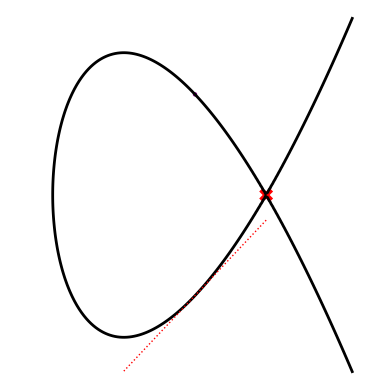

In [39]:
R = PolynomialRing(RR, ['X','y'], 2)
R.inject_variables(verbose=False)
E = y**2 - x**3 + 3*x -2

print("We consider a curve of equation", E, "over R².")

J = matrix(E.gradient())
print("The Jacobian matrix of this polynomial has dimension 1x2.")
print()
print(J)
print()
S = (1, 0)
P = (0,sqrt(2))
print("The point S = (1,0) belongs to the curve:")
print("E(S) = ", E(x=S[0], y=S[1]))
print("The Jacobian matrix evaluated at S has rank",J(x=S[0], y=S[1]).rank(),". P is a singular point of the curve.")


print("The point P = (0,sqrt(2)) belongs to the curve:")
print("E(P) = ", E(x=P[0], y=P[1]))
print("The Jacobian matrix evaluated at P has rank",J(x=P[0], y=P[1]).rank(),". P is a regular point of the curve.")
print("We compute the right kernel of the Jacobian matrix evaluated at P to obtain a vector D spanning the tangent line.")
D = vector(4*J(x=P[0], y=P[1]).right_kernel().basis_matrix())
print("D =",D)


print("We plot the tangent line at P, and the point S.")
var('t')
line_plot = parametric_plot((-4*t, -sqrt(2) - 3*sqrt(2)*t), (t, -.25, 0.25),color='red', linestyle="dotted")
implicit = implicit_plot(E, (x, -2.5, 2.5), (y, -2.5, 2.5), color="black",  linewidth=2)
pt = point(P, color='purple')
pt2 = point(S, color='red', size = 100, marker= 'X')
combined_plot = implicit + line_plot + pt + pt2

combined_plot.show(axes=False, frame=False )


### Gröbner bases

In [40]:
print("We show how to compute Gröbner bases using SageMath.")
FF= GF(31) # Finite field
n = 5 # Dimension of the vector space
m = 4 # Number of polynomials

print("The ordering is chosen when creating the polynomial ring.")
R = PolynomialRing(FF, 'X', n, order='lex') # Polynomial ring with lex order
print(R)

print("We generate", m, "random homogeneous quadratic polynomials, and dehomogenize wiht X0-1.")
P = [ sum([ FF.random_element()*xi*xj for xi in R.gens() for xj in R.gens()])  for _ in range(m)]
P.append( R.gens()[0] - 1)
for p in P :
    print(p)
print("SageMath enables us to compute a (lex) Gröbner bases of an ideal using Ideal().groebner_basis()")
I  = Ideal(P)
gb = I.groebner_basis()
for i in gb:
    print(i)
print("Since the number of polynomials and variables is well-chosen, the last polynomial is univariate, which enables us to find solutions by factoring it.")
print(gb[-1].factor())
print(Ideal(gb).variety())


print("Sometimes, the grevlex Gröbner basis is enough to solve the problem at hand.")
print("This is Lemma 2.44.")
load('UOV.sage')
m = 4
n = 10
q = 251
_, P = KeyGen(q,m,n-m)
R = PolynomialRing(GF(q), 'X', n-1)
X = vector([1]+list(R.gens())) # Dehomogenizing is important!
eqs = [X*p*X for p in P]
sys = eqs + list(jacobian(eqs, R.gens()).minors(m))
I = Ideal(sys) 
gb = I.groebner_basis()
print("For example, the Gröbner basis of the singular locus of a certain quadratic polynomial system of 4 equations in 9 variables is a long sequence:")
print(gb)
print("But it contains n-m =",n-m,"linear polynomials:")
lin = []
for i in gb :
    if i.degree() == 1 :
        lin.append(i)
        print(i)
print("The variety of these linear polynomials is a vector space of solutions to the input polynomials.")
H = [ GF(q).random_element()+sum([GF(q).random_element()*x for x in R.gens()]) for _ in range(m-1)]
V0 = Ideal(lin+H).variety()[0]
x = X([V0[xi] for xi in R.gens()])
print('x=',x[1:])
for i in range(m):
    print("p"+str(i)+"(x) =", x*P[i]*x)

We show how to compute Gröbner bases using SageMath.
The ordering is chosen when creating the polynomial ring.
Multivariate Polynomial Ring in X0, X1, X2, X3, X4 over Finite Field of size 31
We generate 4 random homogeneous quadratic polynomials, and dehomogenize wiht X0-1.
11*X0^2 - 11*X0*X1 + 8*X0*X2 - 7*X0*X3 + 4*X0*X4 + 2*X1^2 + 10*X1*X2 - 4*X1*X3 - 5*X1*X4 + 3*X2^2 + 12*X2*X3 + 13*X2*X4 + 5*X3^2 - 12*X3*X4 + 3*X4^2
-4*X0^2 + 11*X0*X1 + 14*X0*X2 - 12*X0*X3 - 7*X0*X4 - 11*X1^2 + 15*X1*X2 - 2*X1*X3 - X1*X4 + 6*X2^2 + 3*X2*X3 - 14*X2*X4 - 2*X3*X4 + X4^2
-3*X0^2 + 7*X0*X1 + 4*X0*X2 - X0*X3 - 2*X0*X4 - 12*X1^2 - 14*X1*X2 - 3*X1*X3 + 14*X1*X4 - 3*X2^2 - 13*X2*X3 + 2*X2*X4 + 11*X3^2 + 13*X3*X4 + 3*X4^2
10*X0^2 + 9*X0*X1 + 15*X0*X2 + 5*X0*X3 - 12*X0*X4 + 10*X1^2 - 7*X1*X2 - 9*X1*X3 + 12*X1*X4 - 4*X2^2 + 10*X2*X3 + 13*X2*X4 + X3^2 - 12*X3*X4 + X4^2
X0 - 1
SageMath enables us to compute a (lex) Gröbner bases of an ideal using Ideal().groebner_basis()
X0 - 1
X1 + 11*X4^15 - 5*X4^14 + 10*X4^13

<string>:74: DeprecationWarning: invalid escape sequence '\c'


For example, the Gröbner basis of the singular locus of a certain quadratic polynomial system of 4 equations in 9 variables is a long sequence:
Polynomial Sequence with 21 Polynomials in 9 Variables
But it contains n-m = 6 linear polynomials:
X0 - 30*X6 - 4*X7 - 112*X8 - 16
X1 + 70*X6 + 64*X7 - 99*X8 + 56
X2 + 108*X6 - X7 + 103*X8 - 87
X3 + 24*X6 + 76*X7 + 61*X8 + 80
X4 + 57*X6 + 14*X7 + 87*X8 + 92
X5 - 101*X6 - 65*X7 - 112*X8 + 119
The variety of these linear polynomials is a vector space of solutions to the input polynomials.
x= (152, 91, 226, 228, 129, 192, 51, 248, 28)
p0(x) = 0
p1(x) = 0
p2(x) = 0
p3(x) = 0


### Hilbert Series

In [51]:
print("We can use Hilbert series to predict the complexity of computing a Gröbner basis for a specific family of polynomial systems of equations.")
print("Consider a system of 4 homogeneous quadratic polynomials in 4 variables.")
m = 4
n = 4
q = 31
R = PolynomialRing(GF(q), 'X', n)
P = [ sum([ GF(q).random_element()*xi*xj for xi in R.gens() for xj in R.gens()])  for _ in range(m)]
for p in P:
    print(p)
print("The polynomials are drawn uniformly at random, thus we expect that they form a regular sequence, and hence that their Hilbert series is ")
print("  (1-t^2)^m/(1-t)^n.")
HS_sage = Ideal(P).hilbert_series()
print("Sage computes the following Hilbert series for R/I:", HS_sage.factor())
print("The degree of regularity is the maximal degree of an element in a grevlex Gröbner basis, and the first non-positive index in the series.")

PS = PowerSeriesRing(ZZ, 'z', default_prec=40)
PS.inject_variables(verbose=False)
HS = (1-z^2)^m/((1-z)^n)
print(HS)
print('Thus, we expect a degree of regularity of 5, which achieves the Macaulay bound: 4 + 1.')
PS.inject_variables(verbose=False)
print("We verify this prediction by computing a Gröbner basis:")
I = Ideal(P)
gb = I.groebner_basis()
for i in gb:
    print(i.degree(), i)
print("Indeed, 5 is the highest degree in a polynomial of the Gröbner basis.")

We can use Hilbert series to predict the complexity of computing a Gröbner basis for a specific family of polynomial systems of equations.
Consider a system of 4 homogeneous quadratic polynomials in 4 variables.
-11*X0^2 - X0*X1 - 15*X1^2 + 11*X0*X2 + 10*X1*X2 + 8*X2^2 + 2*X0*X3 + 15*X1*X3 + 14*X2*X3 - 3*X3^2
14*X0^2 - 8*X0*X1 + 6*X1^2 + 13*X0*X2 + 2*X1*X2 - 13*X2^2 + 5*X0*X3 - 12*X1*X3 + 11*X2*X3 - 7*X3^2
8*X0^2 + 5*X0*X1 - 12*X1^2 + 13*X0*X2 - 14*X1*X2 + 15*X2^2 + 7*X0*X3 - 8*X1*X3 - 2*X2*X3 - 11*X3^2
12*X0^2 + 3*X0*X1 - 12*X1^2 + 14*X0*X2 + 11*X1*X2 - 4*X2^2 + 4*X0*X3 - 10*X1*X3 + 4*X2*X3 + 2*X3^2
The polynomials are drawn uniformly at random, thus we expect that they form a regular sequence, and hence that their Hilbert series is 
  (1-t^2)^m/(1-t)^n.
Sage computes the following Hilbert series for R/I: (t + 1)^4
The degree of regularity is the maximal degree of an element in a grevlex Gröbner basis, and the first non-positive index in the series.
1 + 4*z + 6*z^2 + 4*z^3 + z^4 + O(z

### Debarre and Manivel Bound

<>:33: DeprecationWarning: invalid escape sequence '\m'
<>:33: DeprecationWarning: invalid escape sequence '\m'
/tmp/ipykernel_17304/1042258155.py:33: DeprecationWarning: invalid escape sequence '\m'
  p+= text('dim($\mathcal{O}$)',(m,m),vertical_alignment='top',color='blue')


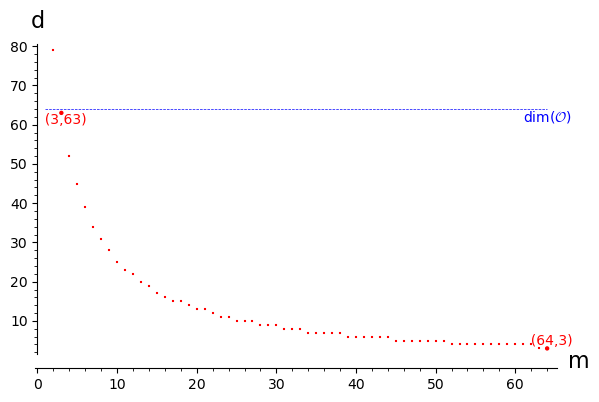

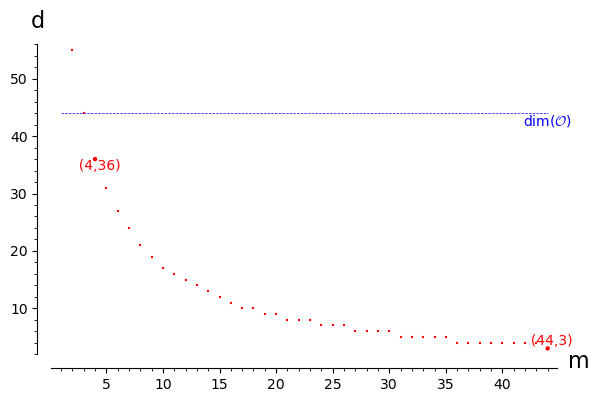

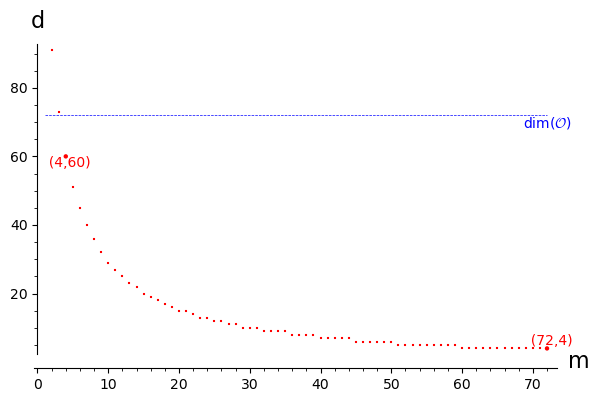

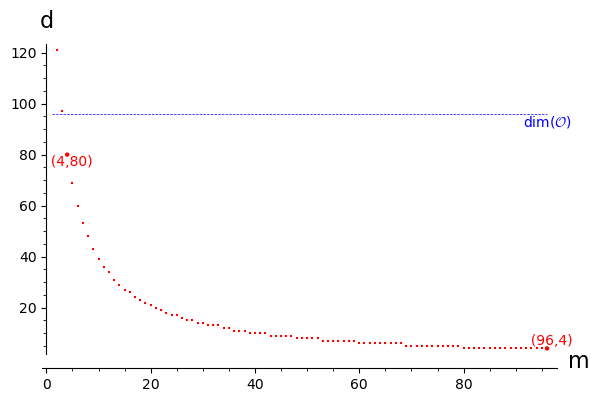

In [54]:
load('params.sage')
load('tools.sage')

for name,q,n,m  in UOVparams :
    points = []

    
    for k in range(2,m+1) :

        r= 2
        
        delta = delta_dm(n-1,r-1,k)
        while delta >= 0 :
            r+=1 
            delta = delta_dm(n-1,r-1,k)
        r-=2
        points.append(((k,borne_debarre_manivel(n-1,k))))
    
    i_star = 0
    while points[i_star][1] > m-1 :
        i_star+=1
    
        
    p=list_plot(points, color='red', size=1, marker='+')#, ticks=(range(2,44),range(1,44)))
    
    p+= text('  (%s,%s)'%(points[-1][0],points[-1][1]),points[-1],vertical_alignment='bottom',color='red')
    p+= point(points[-1], color="red")

    p+= text('  (%s,%s)'%(points[i_star][0],points[i_star][1]),points[i_star],vertical_alignment='top',color='red')
    p+= point(points[i_star], color="red")

    p+= plot(m, (1, m), color='blue', linestyle='dashed', thickness=0.5) 
    p+= text('dim($\mathcal{O}$)',(m,m),vertical_alignment='top',color='blue')


    p.axes_labels(['m', 'd'])
    p.show()
    


### State of the art of the Cryptanalysis of (U)OV

Kipnis-Shamir (OV)

In [52]:
load("UOV.sage")

(A,F), G = KeyGen(251, 8, 8)

S = F[0].inverse()*F[1]
M = G[0].inverse()*G[1]

#print(F[0])
#print()
#print(F[0].inverse())
print("The block structure of the secret endomorphisms highlighted by Lemma 4.6:")
#print(S)
print('The public endomorphism M does not have the same structure:')

#print(M)
print('But its characteristic polynomial is a square: ')
print("chi_M(x)=",M.charpoly().factor())
r=M.charpoly().sqrt()
print('Its root is r=', r,'.\n')
print(r.factor())
print('Compute the right kernel of the evaluation of r:')
O = (r(M)).right_kernel()
print(O)
B = O.basis_matrix()
print("Verify that it is an OV secret key by evaluating the public key on it:")
#for i in range(len(G)):
    #print(f"B^T G_{i}B =")
    #print(B * G[i]* B.T)
    



The block structure of the secret endomorphisms highlighted by Lemma 4.6:
The public endomorphism M does not have the same structure:
But its characteristic polynomial is a square: 
chi_M(x)= (x^2 + 204*x + 154)^2 * (x^6 + 121*x^5 + 29*x^4 + 158*x^3 + 136*x^2 + 213*x + 242)^2
Its root is r= x^8 + 74*x^7 + 18*x^6 + 110*x^5 + 188*x^4 + 81*x^3 + 131*x^2 + 93*x + 120 .

(x^2 + 204*x + 154) * (x^6 + 121*x^5 + 29*x^4 + 158*x^3 + 136*x^2 + 213*x + 242)
Compute the right kernel of the evaluation of r:
Vector space of degree 16 and dimension 8 over Finite Field of size 251
Basis matrix:
[  1   0   0   0   0   0   0   0  56  35  75 105  41 184 162 250]
[  0   1   0   0   0   0   0   0  49 151 240 212 140   0 117  98]
[  0   0   1   0   0   0   0   0  16 101 138 112   0   6 106  26]
[  0   0   0   1   0   0   0   0 192 204 210  91 225  26 129 227]
[  0   0   0   0   1   0   0   0 188  86 147 230 128 130 130 222]
[  0   0   0   0   0   1   0   0  84  54  44  58 198  83 197  28]
[  0   0   0   0   

<string>:74: DeprecationWarning: invalid escape sequence '\c'


### Algorithms of Kipnis, Patarin, Goubin and  Thomae Wolf

In [76]:
###Setup
load("UOV.sage")
print("We demonstrate the algorithm of Kipnis-Patarin-Goubin/Thomae-Wolf.")
q=2**8
n = 25
m = 5
_, P = ROMKeyGen(q,m,n-m)
print("n,m,q=",n,m,q)

r= 4
print('We set r =', r)

print("We verify the Thomae-Wolf bound:")
print(r*(m-1), "<=", n-m)
t = [GF(q).random_element() for _ in  range(m)]
print('The target vector is:')
print(t)

#P = [ upper(p) for p in P]

###Induction: step 0
i=0
s1 = [1] + [0 for _ in range(m-1)] + [GF(q).random_element() for  _ in range(n-m)]
S1 = vector(s1)
S = [S1]
print("The basis is iteratively compueted:")
print("S1=", S1)
    

for i in range(1, m):
    ###Induction: step i
    R = PolynomialRing(GF(q), ['s'+str(i) for i in range(n-1)], n-1)
    si =  list(R.gens())[:i] + [1] + list(R.gens())[i:] 
    Si = vector(si)
    eqs = []
    for Sj in S :
        for p in P[:r]:
            eqs.append(Sj*p*Si + Si*p*Sj)
    I = Ideal(eqs)
    d = I.dimension()
        
    H = []
    j = 0
    while j < d and j < m-1 :
        H.append(R.gens()[j]) 
        j+=1
    while j < d :
        H.append(GF(q).random_element() + sum([GF(q).random_element()*x for x in R.gens()[m-1:]])) 
        j+=1        
    V = (Ideal(eqs+H).variety())[0]


    
    
    fSi = Si([V[s] for s in R.gens()])
    print("S"+str(i+1)+"=", fSi)
    
    S.append(fSi)
matS = matrix(GF(q), m,n, S)
print("S has been computed:")
print(matS)
print("We verify that S is full rank. Rank S=", matS.rank())



R = PolynomialRing(GF(q), 'X', m)
X = vector(R.gens())

if r < m :
    print("We are in the Thomae-Wolf context.")
    print("""We have "linearized" a subset of equations, and must solve a quadratic polynomial system:""")
    eqs = [X*matS*p*matS.T*X for p in P[:r]]
    sys = [X*matS*P[i]*matS.T*X - t[i] for i in range(r,m)]
    for i in range(r) :
        lin = eqs[i]**(q//2)
        coeffs = [ lin.coefficient(x**q) for x in R.gens()]
        Li = sum([coeffs[j]*R.gens()[j] for j in range(m)])
        sys.append( Li-t[i]**(q//2) )
    for i in sys:
        print(i)
    I = Ideal(sys)
    print('The variety is')
    print(I.variety())


if r == m :
    print("We are in the Kipnis-Patarin-Goubin context.")
    print("""We have "linearized" all equations, and must solve a linear system:""")

    eqs = [X*matS*p*matS.T*X for p in P]
    for i in eqs:
        print(i)
    vecs = []
    for i in eqs :
        lin = i**(q//2)
        coeffs = [ lin.coefficient(x**q) for x in R.gens()]
        vecs.append(coeffs)
    M = matrix(vecs)
    t_pow = vector( [ ti**(q//2) for ti in t])
    X = list(M.solve_right(t_pow))
    print("Solution:", X)
    print("Testing P(x) - t:")
    for i in range(len(eqs)) :
       print(eqs[i](X) - t[i])

<string>:74: DeprecationWarning: invalid escape sequence '\c'


We demonstrate the algorithm of Kipnis-Patarin-Goubin/Thomae-Wolf.
n,m,q= 25 5 256
We set r = 4
We verify the Thomae-Wolf bound:
16 <= 20
The target vector is:
[z8^7 + z8^6 + z8^2 + z8 + 1, z8^7 + z8^6 + z8^5 + z8^4 + z8^2 + 1, z8^7 + z8^6 + z8^3 + z8^2, z8^7 + z8^6 + z8 + 1, z8^6 + z8^4 + z8^3 + z8]
The basis is iteratively compueted:
S1= (1, 0, 0, 0, 0, z8^2 + z8, z8^6 + z8^5 + z8^3, z8^5 + z8^4 + z8 + 1, z8^7 + z8^4 + z8^3 + 1, z8^6 + z8^5, z8^7 + z8^6 + z8^5 + z8^4 + z8^2 + z8, z8^7 + z8^6 + z8^5 + z8^3 + z8 + 1, z8^5, z8^5 + z8^4 + z8^2, z8^4 + z8^3 + z8^2 + z8 + 1, z8^5 + z8^4 + z8^2 + z8 + 1, z8^6 + z8^5, z8^7 + z8^3 + z8^2 + z8, z8^7 + z8^6 + z8^3 + z8^2 + z8 + 1, z8^6 + z8^5 + z8^4 + z8^3, z8^5 + z8^4 + z8^2 + z8 + 1, z8^7 + z8^4 + z8 + 1, z8^5 + z8^3 + z8, z8^7 + z8^6 + z8^5 + z8^4 + z8, z8^7 + z8^2 + z8 + 1)
S2= (0, 1, 0, 0, 0, z8^5 + z8^3, z8^7, z8^6 + z8^5 + z8^4 + z8 + 1, z8^5 + z8^4 + z8 + 1, z8^7 + z8^5 + z8^2, z8^7 + z8^4 + z8^2 + 1, z8^7 + z8^6 + z8 + 1, z8^7 + z8^6 +

## State of the art of the cryptanalysis of UOV

In [86]:
load("params.sage")

### Cost of an arithmetic operation in gates
def gates(q):
    """
    Return the cost of one multiplication in Fq in gates following NIST methodology.
    """
    return log(3*2*(log(q, 2)**2 + log(q,2)),2)

### Degree of regularity of semi-regular polynomial sequences
def dreg_semi_reg(n,m) :
    """ 
    HS of a semi-regular quadratic system m eqs in n variables.   
    """
    R.<t> = PowerSeriesRing(ZZ, default_prec=m+1)
    h = (1-t^2)^(m)/(1-t)^(n+1) ### +1 ?
    #print(h)
    L = list(h)
    for i in range(len(L)) :
        if L[i] <= 0 :
            return i
    return len(L)+1

def cost_semi_reg(n,m,q) :
    """
    Compute the bit cost of solving a semi regular system of n variables m equations in Fq assuming "sparse solver" using a hybrid algorithm over Fq.
    """
    d = dreg_semi_reg(n,m)
    
    mini= float(log(binomial(n + d, d)**2 * binomial(n, 2),2))
    k_min = 0
    
    for k in range(1,10) :
        d = dreg_semi_reg(n-k,m)
        
        temp = float(log(q^k * binomial(n-k + d, d)**2 * binomial(n-k, 2),2))
        if temp < mini :
            mini = temp 
            k_min = k
        if k_min > 0 and temp > mini:
            break
    return mini , k_min

###Direct attack
def thomae_wolf(n,m):
    """
    Return k such that a solution of a quadratic system in m eqs and n vars can be found by solving a systme in m-k eqs and vars.
    """
    r = 0
    while r*(m-1) <= n-m :
        r+=1
    return r-1

def cost_direct(n,m,q):
    """
    Cost of forging a signature of an MQ system over Fq in n vars and m eqs.
    """
    r = 0
    if q % 2 :
        if n > 2*m +2 :
            r=1 # Chap 10
    else :
        r = thomae_wolf(n,m)
    cost, k = cost_semi_reg(m-r,m-r,q)
    return cost, r, k

### Kipnis Shamir
def cost_ks(n,m,q) :
    """ 
    Cost of the Kipnis-Shamir attack against UOV(n,m,q)
    """
    return float(log(q^(n-2*m)*n^2.81, 2))

### Intersection 
def cost_inter(n,m,q):
    k = 2
    """while (n < (2*k-1)/(k-1)*m) and (k<=m) :
        k+=1
    k-=1
    """
    N_vars =  n*k - (2*k-1 )*m
    M_eqs = binomial(k+1,2)*m - 2*binomial(k,2)
    cost, i = cost_semi_reg(N_vars,M_eqs,q)
    return cost, i, k


#["Is", 16, 160, 64],
for name, q, n, m in UOVparams:
    print(name, q, n, m)
    g = float(gates(q))

    #Direct
    direct, r, k = cost_direct(n,m,q)
    print("Direct attack:", direct+g,'with TW',r, "and hybrid depth", k)
    #KS
    ks = cost_ks(n,m,q) + g
    print("Kipnis-Shamir:", float(ks))
    inter, k, k_inter = cost_inter(n,m,q)
    print("Intersection:", inter+g,"with k",k_inter ,"with hybrid depth", k)



Is 16 160 64
Direct attack: 167.67668885817704 with TW 1 and hybrid depth 9
Kipnis-Shamir: 155.481508542242
Intersection: 204.18849347663195 with k 2 with hybrid depth 0
Ip 256 112 44
Direct attack: 145.53320590287922 with TW 1 and hybrid depth 2
Kipnis-Shamir: 219.88355483314533
Intersection: 165.71910350769727 with k 2 with hybrid depth 0
III 256 184 72
Direct attack: 217.94538727107565 with TW 1 and hybrid depth 4
Kipnis-Shamir: 349.89609659868364
Intersection: 249.9882739376785 with k 2 with hybrid depth 0
V 256 244 96
Direct attack: 277.88214557679424 with TW 1 and hybrid depth 6
Kipnis-Shamir: 447.0402594207152
Intersection: 311.6348947277433 with k 2 with hybrid depth 0


### Setting the parameters

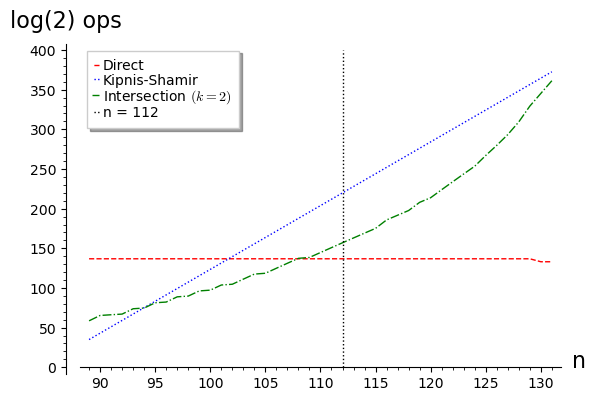

In [87]:

### Plot m, q fixed, n varies.
m =44
q = 256
X = range(2*m+1, 3*m)

listDirect = []
listKS = []
listInter = []
for n in X: 
    direct, r, k = cost_direct(n,m,q)
    listDirect.append(direct)
    
    ks = cost_ks(n,m,q) + g
    listKS.append(ks)

    inter, k, k_inter = cost_inter(n,m,q)
    listInter.append(inter)



ymin = 0
ymax =  400
# Use line() to connect points
p  = line(list(zip(X, listDirect)), color='red',linestyle='--', legend_label='Direct')
p += line(list(zip(X, listKS)), color='blue', linestyle='dotted', legend_label='Kipnis-Shamir')
p += line(list(zip(X, listInter)), color='green', linestyle='dashdot', legend_label='Intersection $(k=2)$')
p += line([(112, ymin), (112, ymax)], color='black', linestyle=':', legend_label='n = 112')
p.axes_labels(['n', 'log(2) ops'])
p.show()







# Contributions

## Genericity results on UOV

In [88]:
load('UOV.sage')
load('tools.sage')
### Define a collection of primes to test.

primes =  [31, 251, 1021, 4093]

### Define families of UOV parameters with different expected dimension of the singular locus, and of various rank defects.

parameters = [
    #n, m, o. In all cases, n > 2o.
    [10, 4, 4], #Regular UOV               ; r=1 dim 1
    [10, 5, 4], #Regular UOV               ; r=1 dim 1
    [10, 6, 4], #O has the same dim as V   ; r=1 dim 3 
    #[10, 8, 4],  #Non-regular variety      ; r=1 dim 5, r=2 dim 4, r=3 dim 1
    #[10, 10, 4], #Non-regular variety      ; r=1 dim 7, r=2 dim 8, r=3 dim 7, r=4 dim 4
]

for n,m,o in parameters:
    print("Parameter set:", n,m,o)
    print(n-o,m)
    keys = []
    for p in primes : 
        _, G = KeyGen(p,o,n-o, m)
        keys.append([G,p])
    r = min(1, n-o)
    delta = r*(m - r) + o - r*(n - o)
    while delta > 0 and r <= min(n-o, m):
        print("rank defect:",r, "dimension", delta)
        
        for G,p in keys:
            vars_X = ['X'+str(i) for i in range(n)]
            vars_Y = ['Y'+str(i) for i in range((m-r)*r)]
            variables = vars_X + vars_Y
            R = PolynomialRing(GF(p), variables, n + (m-r)*r)
            X = vector(R.gens()[:n])
            Y = block_matrix(R, 1, 2, [
                matrix.identity(r), matrix(R, r, m-r, R.gens()[n:])
            ])
            #print(X)
            #print(Y)
            eqs = [X*g*X for g in G]
            J = matrix([(g+g.T)*X for g in G])
            H = [GF(p).random_element() + sum([GF(p).random_element()*xi for xi in X]) for _ in range(delta)]
            
            sys = eqs + (Y*J).coefficients() + H
            file = "/tmp/sing"+str(m)+"_"+str(r)+"_"+str(p)
            ToMSolve(sys, file+".ms")
            os.system("msolve -g2 -f "+file+".ms -o "+file)#+" > "+file+".log")
            gb= FromMsolve(file, R)
            I = Ideal([i.lt() for i in gb])
            print("Prime:", p)
            #print("Ideal is radical?", Ideal(eqs).radical()==Ideal(eqs))
            print("Singular locus has dimension delta?",I.dimension()==0)
        
        r+=1
        delta = r*(m - r) + o - r*(n - o)
    print( )
    


<string>:74: DeprecationWarning: invalid escape sequence '\c'


Parameter set: 10 4 4
6 4
rank defect: 1 dimension 1
Prime: 31
Singular locus has dimension delta? True
Prime: 251
Singular locus has dimension delta? True
Prime: 1021
Singular locus has dimension delta? True
Prime: 4093
Singular locus has dimension delta? True

Parameter set: 10 5 4
6 5
rank defect: 1 dimension 2
Prime: 31
Singular locus has dimension delta? True
Prime: 251
Singular locus has dimension delta? True
Prime: 1021
Singular locus has dimension delta? True
Prime: 4093
Singular locus has dimension delta? True

Parameter set: 10 6 4
6 6
rank defect: 1 dimension 3
Prime: 31
Singular locus has dimension delta? True
Prime: 251
Singular locus has dimension delta? True
Prime: 1021
Singular locus has dimension delta? True
Prime: 4093
Singular locus has dimension delta? True



### ``x in O?`` for VOX and UOV hat plus.

In [89]:
import itertools   
load("tools.sage") #I/O 
load("UOV.sage")   #KeyGen for VOX and UOV
load("VOX.sage")

flag = False

def one_vector_FOX(G,x,t, verbose = False) :
    """ 
    Perform a key recovery on FOX from one known vector in the secret UOV subspace, using an enumerative approach.
    Public key G, vector x, hp parameter t.
    Return [] if the attack failed. This is also a membership test for x in O. 
    """
    n = G[0].dimensions()[0]
    o = len(G)
    v = n-o
    c = v-o
    if verbose: 
        print("First, we compute the right kernel of the Jacobian of the system at x.")
    J = matrix([x*g for g in G]) #This is (1/2) the Jacobian of the public key evaluated at x.
    C=matrix(J.right_kernel().basis()) #This is the change of variables that restricts to the kernel of the Jacobian.
    if verbose :
        print(f"Then, we restrict the public key equations to this subspace, which has dimension {C.dimensions()[0]}.")
    G3 = [C*g*C.transpose() for g in G] #This is the restriction of the public key to the kernel of J.

    N = G3[0].dimensions()[0]
    R = PolynomialRing(GF(q), 'X', N-1)
    X = vector(list(R.gens())+[1]) # we arbitrarily choose to set one of the hyperplanes to xN=1 which dehomogenizes the equations.
    global flag
    if verbose:
        print(f"Next, we compute a grevlex Grobner basis for the ideal defined by the equations of this restriction to which we add o-2t-1={o-2*t-1} hyperplanes to obtain a zero-dimensional intersection with Ot.")
        print("X = ", X)
    eqs = [X*g*X for g in G3]+[X*vector([GF(q).random_element() for _ in range(N)]) for _ in range(o-2*t-1)] #Here we add 1 less hyperplane to compensate for xN-1 which was accounted for earlier.
    ToMSolve(eqs, "/tmp/ovox.ms")
    try:
        if flag :
            raise Exception("This branch will fail")
        if verbose :
            verb = "-v2"
        else :
            verb = ""
        os.system("msolve "+verb+" -g2 -t1 -f /tmp/ovox.ms -o /tmp/ovox.o > /tmp/ovox.log")
        gb = FromMsolve("/tmp/ovox.o", R)
    except:
        flag = True
        if verbose :
            print("msolve not found, defaulting to sage (this may take some time).")
        gb = Ideal(eqs).groebner_basis(algorithm='libsingular:groebner')[::-1]
    if len(gb) == 1 :
        if verbose :
            print("The ideal is the trivial ideal.")
        return []

    
    lgb = [ i.lt() for i in gb]
    print(factor(Ideal(lgb).hilbert_series()))
    z = var('z')
    print(        (1+z)^(o)*(1-z)^(o-(N -(o-2*t-1) )) 
    )
    
    
    M = [[gb[i].coefficient(X[j]) for j in range(N-1)] + [0]
                for i in range(o-1)]
    M = matrix(GF(q), M)
    for i in range(o-1) :
        M[i,-1] = gb[i]([0 for _ in range(N-1)])
    
    if verbose :
        print(f"There are {o-1} polynomials of the Groebner basis that are linear:")
        for g in gb[:o-1] :
            print(g)
        print("The intersection of the hyperplanes in the basis is Ot.")
    D = matrix((M.right_kernel()).basis())
    return D*C

def x_in_O(G,x,t) :
    l = one_vector_FOX(G,x,t)
    if l == [] :
        return False
    #print(l)
    return True 


print("We demonstrate the one vector key recovery.")

q,o,v,t = 251, 48, 54, 6 # I
#q,o,v,t = 1021, 70, 77, 7 #III
#q,o,v,t = 4093, 96, 104, 8 # V
n=o+v
print('We use parameters for security level 1: q,o,v,t=',q,o,v,t)
print("With msolve, all security levels are solved in less than 15 seconds.")
print("Without msolve, it will take some time ~10 minutes to complete the computations for level 5, uncomment the above lines if you wish to try or if you have msolve installed.")

print("KeyGen will take some time.")

(A,Sp,F, G), G2 = FOXKeyGen(q,o,v,t)
print("These parameters are vulnerable to the one vector key recovery:", n-2*o+1<o-2*t)
    
print("An oracle gives us a vector of the underlying UOV secret subspace:")
O = span(A.inverse().columns()[:o])
x = O.random_element()
print("x=",x)

print("We compute a subspace of O of large enough dimension using the approach of Section 4.3.")
O2 = one_vector_FOX(G2, x, t, verbose=True)
print("The subspace we have computed has dimension d =", O2.dimensions()[0], " and t =",t)
#print(O2)

print(" ")
print("We test the function on a random vector:")
x = vector(GF(q), [GF(q).random_element() for _ in range(o+v)])
print("x=",x)

O2 = one_vector_FOX(G2, x, t, verbose=True)

if O2 == [] :
    print("Therefore, x is not in O.")
print(" ")


<string>:74: DeprecationWarning: invalid escape sequence '\c'


We demonstrate the one vector key recovery.
We use parameters for security level 1: q,o,v,t= 251 48 54 6
With msolve, all security levels are solved in less than 15 seconds.
Without msolve, it will take some time ~10 minutes to complete the computations for level 5, uncomment the above lines if you wish to try or if you have msolve installed.
KeyGen will take some time.
These parameters are vulnerable to the one vector key recovery: True
An oracle gives us a vector of the underlying UOV secret subspace:
x= (58, 151, 161, 240, 25, 19, 112, 51, 33, 71, 42, 217, 14, 169, 69, 175, 129, 176, 36, 26, 32, 179, 120, 215, 62, 191, 140, 116, 212, 70, 142, 207, 40, 37, 126, 110, 160, 239, 153, 165, 75, 5, 76, 110, 154, 109, 179, 217, 153, 112, 170, 215, 67, 40, 107, 150, 241, 75, 87, 111, 91, 39, 147, 244, 232, 184, 103, 37, 131, 185, 242, 208, 167, 105, 138, 70, 98, 241, 21, 146, 218, 212, 89, 11, 105, 66, 93, 32, 78, 118, 110, 177, 36, 171, 18, 226, 222, 100, 249, 181, 28, 188)
We compute a sub


--------------- INPUT DATA ---------------
#variables                      53
#equations                      83
#invalid equations               0
field characteristic           251
homogeneous input?               0
signature-based computation      0
monomial order                 DRL
basis hash table resetting     OFF
linear algebra option            2
initial hash table size     131072 (2^17)
max pair selection             ALL
reduce gb                        1
#threads                         1
info level                       2
generate pbm files               0
------------------------------------------
Dimension of quotient: 64
------------------------------------------------------------------------------------
msolve overall time           2.09 sec (elapsed) /  2.08 sec (cpu)
------------------------------------------------------------------------------------


(t + 1)^6
-(z + 1)^48*(z - 1)^29
There are 47 polynomials of the Groebner basis that are linear:
X46 + 43*X47 - 56*X48 + 38*X49 - 61*X51 + 67*X52 - 65
X45 + 111*X47 + 69*X48 + 77*X49 + 97*X50 - 81*X51 - 115*X52 - 92
X44 - X47 - 50*X48 - 109*X49 + 36*X50 - 100*X51 - 79*X52 - 10
X43 - 80*X47 + 5*X48 - 99*X49 + 75*X50 - 79*X51 + 43*X52 - 82
X42 + 66*X47 + 107*X48 - 47*X49 - 75*X50 + 64*X51 + 78*X52 + 92
X41 - 17*X47 + 54*X48 + 56*X49 - 62*X50 - 102*X51 + 41*X52
X40 - 96*X47 + 16*X48 + 46*X49 + 9*X50 - 111*X51 + 7*X52 + 115
X39 - 58*X47 - 82*X48 + 118*X49 + 9*X50 - 109*X51 + 5*X52 - 18
X38 + 41*X47 - 68*X48 - 84*X49 - 101*X50 + 32*X51 + 67*X52 - 26
X37 + 67*X47 + 23*X48 + 123*X49 + 22*X50 - 37*X51 + 34*X52 + 53
X36 + 97*X47 - 65*X48 + 9*X49 - 87*X50 + 41*X51 + 71*X52 - 14
X35 - 28*X47 + 105*X48 + 55*X49 + 100*X50 + 76*X51 + 100*X52 - 106
X34 - 118*X47 - 118*X48 + 121*X49 + 55*X50 - 15*X51 + 33*X52 + 48
X33 + 26*X47 - 83*X48 + 51*X49 + 3*X50 + 39*X51 + 32*X52 + 85
X32 + 23*X47 - 84*X48 + 97


--------------- INPUT DATA ---------------
#variables                      53
#equations                      83
#invalid equations               0
field characteristic           251
homogeneous input?               0
signature-based computation      0
monomial order                 DRL
basis hash table resetting     OFF
linear algebra option            2
initial hash table size     131072 (2^17)
max pair selection             ALL
reduce gb                        1
#threads                         1
info level                       2
generate pbm files               0
------------------------------------------


The ideal is the trivial ideal.
Therefore, x is not in O.
 


------------------------------------------------------------------------------------
msolve overall time           2.64 sec (elapsed) /  2.64 sec (cpu)
------------------------------------------------------------------------------------


### Subfield attack on VOX.

In [91]:
load("params.sage")
load("tools.sage")
load('VOX.sage')
load("UOV.sage")
import os 

print("We begin by estimating the attack cost.")
def a_op(q) :
    "cost of arithmetic in Fq"
    return 2*log(q,2)^2 + log(q,2)
def dreg_semi_reg(n,m) :
    """ 
    HS of a semi-regular quadratic system m in n variables.   
    """
    R.<t> = PowerSeriesRing(ZZ)
    h = (1-t^2)^(m)/(1-t)^(n) 
    #print(h)
    L = list(h)
    for i in range(len(L)) :
        if L[i] <= 0 :
            return i
    return len(L)+1


####SUBFIELD ATTACK



### Estimating attack cost.
for i in range( len(VOXparams)) :
    p=VOXparams[i]
    q, o, v, c, t, name = p 
    
    for c1 in c.divisors()[::-1]:
        c2 = c/c1
        #print(c1, c2, p)
        N = (o+v)*c2 
        O = o*c2 
        if N > o*c :
            continue
        if O<=t :
            continue
        
        print(i, name,'with l=',c2)
        
        d = dreg_semi_reg(N-O+t,o*c)
        Cost =float(log(a_op(q**c2)*(o*d)*binomial(N-O+t+d-1, d)^2.81  , 2))  
        ref = float(log(q^(3*t)*log(q)^2, 2))
        if Cost > ref :
            print("Cost exceeds security level.")
            continue
        
        print(Cost, d)
        


We begin by estimating the attack cost.
0 I with l= 1
38.10283499505032 3
0 I with l= 2
67.60916761948067 6
3 Ic with l= 3
70.96779546865294 6
4 III with l= 1
41.15498249065712 3
5 IIIa with l= 3
55.40197252889394 4
5 IIIa with l= 5
87.51613610947885 7
8 V with l= 1
43.71937387393204 3
8 V with l= 2
69.31973416867493 5
10 Vb with l= 2
54.6254810653312 4


<string>:74: DeprecationWarning: invalid escape sequence '\c'


In [92]:
###  Generate input files and run attack
p = VOXparams[5]

q, o, v, c, t, name = p

for c1 in c.divisors()[::-1]:
    c2 = c/c1
    #print(c1, c2, p)
    N = (o+v)*c2 
    O = o*c2 
    if N > o*c :
        #print("Attack does not apply to",name)
        #print('with l=',c2)
        continue
    if O<=t :
        #print("Attack does not apply to",name)
        #print('with l=',c2)
        continue
    print("Applying attack to",name)
    print('with l=',c2)
    d = dreg_semi_reg(N-O+t+1,o*c)
    Cost =float(log(  binomial(N-O+t+1+d, d)^2.81  , 2))
    ref = float(log(q^(3*t)*log(q)^2, 2))
    if Cost > ref :
        continue
    print(name, c,c1, Cost, N, "dreg:", d)
    
    print("Generating files")
    (A,S,F, G), G2 = hpKeyGen(next_prime(q**c2), O,N-O, o*c, t)
    dim = O-t-1
    R = PolynomialRing(GF(next_prime(q**c2)), 'X', N-1-dim)
    X = vector([1] + [GF(next_prime(q**c2)).random_element() for _ in range(dim)] + list(R.gens())) #dehomogeneize + reach dimension 0
    file = '/tmp/VOX'+name+'_'+str(c1)
    eqs =  [X*g*X for g in G2]
    ToMSolve(eqs, file+'.ms')
    print("Solving")
    os.system("msolve -v2 -g2 -t1 -f "+file+".ms -o "+file + ".o > "+file+".log")
    gb = FromMsolve(file+".o", R)[:N-O]
    print(gb)
    print(name,c1, "Done")
    break

Applying attack to IIIa
with l= 3
IIIa 15 5 48.82211944055681 33 dreg: 5
Generating files
Solving



--------------- INPUT DATA ---------------
#variables                      25
#equations                      75
#invalid equations               0
field characteristic    1064332267
homogeneous input?               0
signature-based computation      0
monomial order                 DRL
basis hash table resetting     OFF
linear algebra option            2
initial hash table size     131072 (2^17)
max pair selection             ALL
reduce gb                        1
#threads                         1
info level                       2
generate pbm files               0
------------------------------------------


[X17 - 39864198*X18 - 288599095*X19 - 169035018*X20 + 126295144*X21 - 414830326*X22 + 295061544*X23 - 14954967*X24 - 134962108, X16 + 394067142*X18 + 314162044*X19 - 115424015*X20 - 178024754*X21 - 98897265*X22 - 167068597*X23 - 302600510*X24 - 147030517, X15 - 412092462*X18 - 256003269*X19 - 418936623*X20 + 527189709*X21 + 52175425*X22 - 371086503*X23 + 68460819*X24 + 323375624, X14 - 295133736*X18 + 220377055*X19 + 334830872*X20 + 212850799*X21 + 356962461*X22 + 487885794*X23 - 350851560*X24 + 459041456, X13 - 340104510*X18 - 360821910*X19 + 72910622*X20 - 279142066*X21 + 179826358*X22 + 489823788*X23 + 414064949*X24 - 58015926, X12 + 16208895*X18 - 383861283*X19 - 99726889*X20 + 309995166*X21 + 274814921*X22 - 313550650*X23 + 179703479*X24 + 297275031, X11 + 311969446*X18 - 467318100*X19 - 356469829*X20 - 432042053*X21 + 409734385*X22 + 376587529*X23 - 185675148*X24 + 191530886, X10 - 471155315*X18 - 143847337*X19 - 497519488*X20 + 12255974*X21 + 446725979*X22 + 127143346*X23 - 4237

Dimension of quotient: 128
------------------------------------------------------------------------------------
msolve overall time          92.14 sec (elapsed) / 92.10 sec (cpu)
------------------------------------------------------------------------------------


## Isotropic subspaces of quadratic forms over finite fields.

### Study of one quadratic form.

In [93]:
load("UOV.sage")
load('tools.sage')
load('normal.sage')
load('params.sage')

import time 


print("Application of the algorithm on NIST-equivalent odd-characteristic UOV parameters")
for name, q, n, m in UOVparams:
    q = next_prime(q)
    P = random_matrix(GF(q), 2*m+1, 2*m+1)
    P = P + P.T
    t0 = time.time()
    B = reid_form(P)
    dt = time.time() - t0
    print(name+"-o",q,2*m+1, dt)
    print(float(log(n^3 + q^2 * n,2)))
print( )
print("Detailed algorithm on a small example.")
n = 11
q = 31
P = random_matrix(GF(q), n-1, n-1)
P = P + P.T
B = quadric_normal_form(P, verbose=True)


<string>:74: DeprecationWarning: invalid escape sequence '\c'


Application of the algorithm on NIST-equivalent odd-characteristic UOV parameters
Is-o 17 129 2.3089945316314697
21.98197971457234
Ip-o 257 89 0.9692866802215576
23.06946812407811
III-o 257 145 4.1483988761901855
24.131831218776238
V-o 257 193 10.139908075332642
24.86904196955775

Detailed algorithm on a small example.
[17 30  3  8  1 28  4 12 20 28]
[30 14 16 19 30 16 24  3 28 15]
[ 3 16  5 16 11  6  4 18 23 13]
[ 8 19 16 29  2 15  6 16 22 21]
[ 1 30 11  2  7  8  2  8 16 28]
[28 16  6 15  8 29  2 26  1 27]
[ 4 24  4  6  2  2 26  2 21 25]
[12  3 18 16  8 26  2 15 27  6]
[20 28 23 22 16  1 21 27 26  8]
[28 15 13 21 28 27 25  6  8  0] 

[17 30  3  8  1 28  4 12 20 11]
[30 14 16 19 30 16 24  3 28 16]
[ 3 16  5 16 11  6  4 18 23 10]
[ 8 19 16 29  2 15  6 16 22 13]
[ 1 30 11  2  7  8  2  8 16 27]
[28 16  6 15  8 29  2 26  1 30]
[ 4 24  4  6  2  2 26  2 21 21]
[12  3 18 16  8 26  2 15 27 25]
[20 28 23 22 16  1 21 27 26 19]
[11 16 10 13 27 30 21 25 19 23] 

[17  0  0  0  0  0  0  0  0  0]
[ 0

# Study of two quadratic forms

In [94]:
load("normal.sage")
load('params.sage')
###
print("We demonstrate the normal form algorithm (assuming suitable diagonalisations)")

q= 17
d1 = diagonal_matrix(GF(q**2),[1 for _ in range(7)])
d2 = diagonal_matrix(GF(q**2), ([GF(q**2)(i+1) for i in range(7)]))
print(d1)
print()
print(d2)

C = simultaneous_diagonal_to_witt(d1.inverse()*d2, verbose=True)

print(' ')
print(C*d1*C.transpose())
print(' ')
print(C*d2*C.transpose())



We demonstrate the normal form algorithm (assuming suitable diagonalisations)
[1 0 0 0 0 0 0]
[0 1 0 0 0 0 0]
[0 0 1 0 0 0 0]
[0 0 0 1 0 0 0]
[0 0 0 0 1 0 0]
[0 0 0 0 0 1 0]
[0 0 0 0 0 0 1]

[1 0 0 0 0 0 0]
[0 2 0 0 0 0 0]
[0 0 3 0 0 0 0]
[0 0 0 4 0 0 0]
[0 0 0 0 5 0 0]
[0 0 0 0 0 6 0]
[0 0 0 0 0 0 7]
First write the Euclidean division of the characteristic polynomial by the chosen singular values:
f(X) = (X-a)g(X)
X-a =  y + 1
yielding a =  16
Then find the remainder of this division:
Find values of bi s.t. -2*y^2*b0 - 2*y^2*b1 - 2*y^2*b2 - 7*y*b0 + 8*y*b1 + 6*y*b2 + 5*b0 - 6*b1 - 4*b2  =  4*y^2 + 3*y - 4
ie the linear system:
-7*b0 + 8*b1 + 6*b2  =  3
-2*b0 - 2*b1 - 2*b2  =  4
and constant term:  5*b0 - 6*b1 - 4*b2  =  13
ie  
 [ 5 11 13]
[10  8  6]
[15 15 15] X =  (13, 3, 4)
where X =  (12, 9, 11)
We conclude the Reid-target is:
[16 12  9 11| 1  1  1]
[12  0  0  0| 1  0  0]
[ 9  0  0  0| 0  2  0]
[11  0  0  0| 0  0  3]
[-----------+--------]
[ 1  1  0  0| 0  0  0]
[ 1  0  2  0| 0  0